In [1]:
# Install Libraries (run once)

%pip install pandas numpy scikit-learn matplotlib seaborn joblib

# Imports

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import joblib

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Load Dataset

df = pd.read_csv("../data/spam.csv", encoding="latin-1")

# Select Required Columns

df = df[["v1", "v2"]]

df.columns = [
    "label",
    "message"
]

# Convert Labels

df["label"] = df["label"].map({
    "ham": 0,
    "spam": 1
})

# Remove Missing Values

df = df.dropna()

# Convert Text

df["message"] = df["message"].astype(str)

print("Dataset Shape:", df.shape)

print("\nClass Distribution:")

print(df["label"].value_counts())

df.head()

Dataset Shape: (5572, 2)

Class Distribution:
label
0    4825
1     747
Name: count, dtype: int64


,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [3]:
# Features and Labels

X = df["message"]

y = df["label"]

# Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# TF-IDF

vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=10000,
    ngram_range=(1,2)
)

X_train_vec = vectorizer.fit_transform(X_train)

X_test_vec = vectorizer.transform(X_test)

print("Vectorization Complete")

Vectorization Complete


In [7]:
models = {

    "Naive Bayes":
        MultinomialNB(),

    "Logistic Regression":
        LogisticRegression(
            max_iter=1000
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=200,
            random_state=42
        )
}

best_model = None

best_model_name = ""

best_accuracy = 0

for name, model in models.items():

    model.fit(
        X_train_vec,
        y_train
    )

    predictions = model.predict(
        X_test_vec
    )

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    print(f"{name}: {accuracy:.4f}")

    if accuracy > best_accuracy:

        best_accuracy = accuracy

        best_model = model

        best_model_name = name

print("\nBest Model:", best_model_name)

print(
    "Best Accuracy:",
    round(best_accuracy * 100, 2),
    "%"
)

Naive Bayes: 0.9668
Logistic Regression: 0.9650
Random Forest: 0.9722

Best Model: Random Forest
Best Accuracy: 97.22 %


              precision    recall  f1-score   support

           0       0.97      1.00      0.98       966
           1       1.00      0.79      0.88       149

    accuracy                           0.97      1115
   macro avg       0.98      0.90      0.93      1115
weighted avg       0.97      0.97      0.97      1115



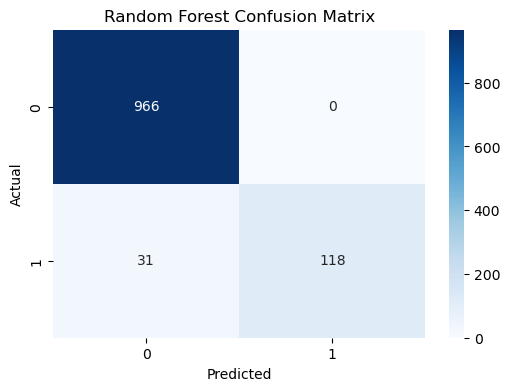

In [9]:
# Predictions

y_pred = best_model.predict(
    X_test_vec
)

print(
    classification_report(
        y_test,
        y_pred
    )
)

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    f"{best_model_name} Confusion Matrix"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [6]:
joblib.dump(
    best_model,
    "../models/spam_model.pkl"
)

joblib.dump(
    vectorizer,
    "../models/vectorizer.pkl"
)

print(
    f"{best_model_name} saved successfully!"
)

Random Forest saved successfully!
